In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

# Standard library imports
import argparse
import importlib.util
import inspect
import json
import math
import os
import pickle
import random
import shutil
import socket
import subprocess
import sys
import tempfile
import warnings
from functools import reduce

# Third-party imports
import librosa
import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from matplotlib import cm
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import umap
from pathlib import Path
import cv2
from IPython.display import Audio, display

from pytorch_grad_cam import GradCAM, HiResCAM, ScoreCAM, GradCAMPlusPlus, AblationCAM, XGradCAM, EigenCAM, FullGrad
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget, BinaryClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Local imports
import commons
import lightning_wrapper
import losses
import models
import utils
import train
from cough_datasets import (
    CoughDatasets,
    CoughDatasetsCollate,
    CoughDatasetsProcessorCollate,
    CoughDetectionRatioBatchSampler,
    CoughDiseaseBinaryBatchSampler,
    PatientBatchSampler
)

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


/tmp/ipykernel_3062559/2035995607.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis")


In [2]:
parser = train.parse_args()
args = parser.parse_args(["--init", "--model_name", "dev", "--pooling_model",
                    "PEFTWavLM_Try1", "--feature_dim", "1024", "--config_path", "configs/general.json"])

model_dir = os.path.join("./logs", args.model_name)
os.makedirs(model_dir, exist_ok=True)
port = None

config_path = args.config_path if args.init else os.path.join(model_dir, "config.json")
hps = train.load_config(config_path, model_dir, args)

df_train, df_test = train.load_data(hps)
collate_fn = train.get_collate_fn(hps)
target_labels = df_train[hps.data.target_column]

splitter, num_folds = train.create_data_split(df_train, target_labels, use_kfold=hps.train.use_Kfold)

for fold, (train_idx, val_idx) in enumerate(splitter):
    train_fold = df_train.iloc[train_idx].reset_index(drop=True)
    val_fold = df_train.iloc[val_idx].reset_index(drop=True)
    
    # Compute statistics
    if hps.data.acoustic_feature and hps.data.mean_std_norm:
        utils.compute_spectrogram_stats_from_dataset(
            train_fold, 
            hps.data, 
            pickle_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle"
        )
    else:
        utils.compute_wav_stats(
            train_fold, 
            "path_file", 
            pickle_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle"
        )
    
    # Create datasets
    train_dataset = CoughDatasets(
        train_fold.values, 
        hps.data,
        wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", 
        train=False
    )
    val_dataset = CoughDatasets(
        val_fold.values, 
        hps.data,
        wav_stats_path=f"{hps.model_dir}/wav_stats_fold_{fold}.pickle", 
        train=False
    )
    
    # Create sampler
    sampler = train.create_sampler(train_fold, hps)
    #sampler = None
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset, 
        num_workers=28, 
        sampler=sampler, 
        batch_size=hps.train.batch_size,
        pin_memory=True, 
        collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_dataset, 
        num_workers=28, 
        shuffle=False, 
        batch_size=hps.train.batch_size,
        pin_memory=True, 
        collate_fn=collate_fn
    )
    break

batch = next(iter(train_loader))
wavnames, audio1, audio2, attention_masks, dse_ids, [patient_ids, _, tabular_ids] = batch
labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

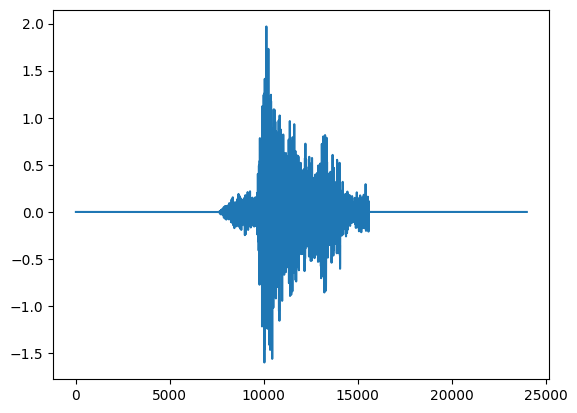

In [3]:
selected_index = random.randint(0, len(audio1) - 1)
audio_np = audio1[selected_index].cpu().numpy().reshape(-1)

display(Audio(audio_np, rate=train_dataset.sampling_rate))
plt.plot(audio_np)

In [4]:
wavnames[selected_index]

'/run/media/fourier/Data1/Pras/DatabaseLLM/coda/wavs/longitudinal_data/1639976827224-recording-1.wav'

In [5]:
audio_np.shape

(24000,)

['add_background_noise']


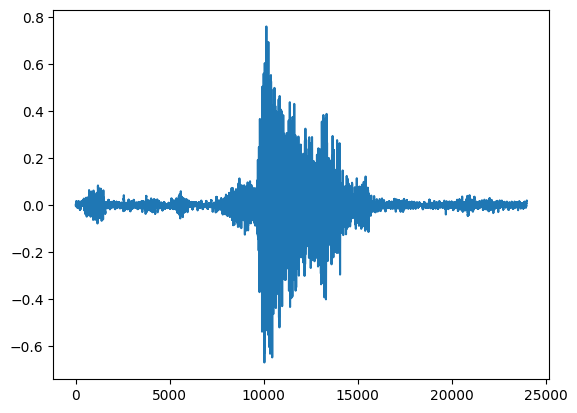

In [41]:
audio_aug, applied_effects = train_dataset.data_augmentator(torch.from_numpy(audio_np).unsqueeze(0), train_dataset.sampling_rate, return_effects=True)
audio_aug = audio_aug.squeeze(0).numpy()

print(applied_effects)
display(Audio(audio_aug, rate=train_dataset.sampling_rate))
plt.plot(audio_aug)